# Preprocessing dan Ekstraksi Fitur

## Preprocessing: Penanganan Outliers dan Interpolasi

Pada tahap _Data Understanding_, kita telah mengidentifikasi adanya _missing values_ dan _outliers_. Untuk menangani masalah ini dan mempersiapkan data agar bisa diekstrak fiturnya secara berkesinambungan, kita menerapkan pembersihan data menggunakan metode Rentang Interkuartil (IQR) dan mengisi kekosongan data menggunakan **interpolasi linier**.

### Deteksi dan Visualisasi Outlier (Metode IQR)

Metode _Interquartile Range_ (IQR) digunakan untuk mengidentifikasi nilai-nilai yang menyimpang atau berada di luar batas kewajaran. Data polutan yang nilainya lebih rendah dari _lower bound_ atau lebih tinggi dari _upper bound_ diklasifikasikan sebagai outlier.

Jumlah outlier (IQR): 4
Batas Bawah: 0.00 | Batas Atas: 0.00


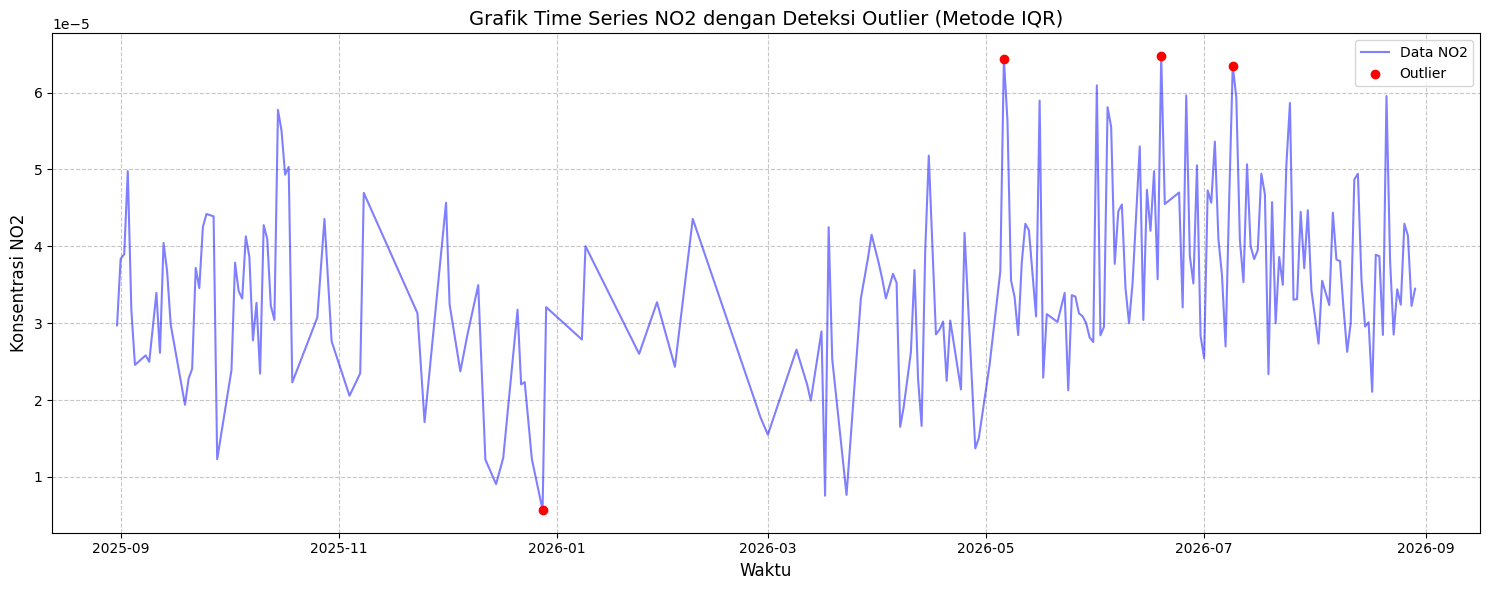

In [1]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt # Import matplotlib untuk visualisasi

# 1. Load & Clean Data
import pandas as pd
import matplotlib.pyplot as plt

# 1. Baca data
df = pd.read_csv("../../data/polutan/NO2_Timeseries.csv")

# Pastikan kolom tanggal berformat datetime agar sumbu X rapi
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    
    # Mengurutkan data berdasarkan tanggal dari yang paling lama ke terbaru
    df = df.sort_values(by='date')
    
    # Jadikan tanggal sebagai indeks agar sumbu X pada grafik otomatis menyesuaikan
    df = df.set_index('date')

df_clean = df.dropna(subset=['NO2']).copy()

# 2. Deteksi Outlier dengan Metode IQR
Q1 = df_clean['NO2'].quantile(0.25)
Q3 = df_clean['NO2'].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Buat kolom penanda (True jika nilainya di luar batas IQR)
df_clean['Outlier'] = (df_clean['NO2'] < batas_bawah) | (df_clean['NO2'] > batas_atas)

jumlah_outlier = df_clean['Outlier'].sum()
print("Jumlah outlier (IQR):", jumlah_outlier)
print(f"Batas Bawah: {batas_bawah:.2f} | Batas Atas: {batas_atas:.2f}")

# 3. Visualisasi Grafik Time Series
plt.figure(figsize=(15, 6))

# Filter baris yang terdeteksi sebagai outlier
data_outlier = df_clean[df_clean['Outlier']]

# Plot garis tren utama untuk seluruh data NO2 (warna biru)
plt.plot(df_clean.index, df_clean['NO2'], color='blue', label='Data NO2', alpha=0.5)

# Plot titik khusus (scatter) untuk nilai outlier (warna merah)
plt.scatter(data_outlier.index, data_outlier['NO2'], color='red', label='Outlier', zorder=5)

# Pengaturan label dan judul
plt.title('Grafik Time Series NO2 dengan Deteksi Outlier (Metode IQR)', fontsize=14)
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Konsentrasi NO2', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Tampilkan grafik
plt.show()

### Penanganan Outlier dan Interpolasi Data

Setelah mendeteksi keberadaan outlier, langkah selanjutnya adalah menandainya sebagai nilai kosong (`NaN`). Kemudian, metode interpolasi linier diterapkan pada keseluruhan dataset untuk mengisi nilai kosong (`NaN`) tersebut. Di akhir proses, teknik _backward fill_ (`bfill`) serta _forward fill_ (`ffill`) dimanfaatkan guna mengatasi nilai kosong pada bagian pinggir atau awalan dan akhiran rangkaian data yang tidak bisa diinterpolasi linier.

```python
import pandas as pd
import numpy as np

# 1. Baca file time series
df = pd.read_csv("NO2_Timeseries.csv")

# 2. Hitung Kuartil dan IQR dari kolom NO2
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

# 3. Tentukan ambang batas outlier
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# 4. Ganti nilai outlier menjadi kosong (NaN)
# Menggunakan fungsi where: mempertahankan nilai yang di dalam batas, sisanya diubah ke np.nan
df['NO2'] = df['NO2'].where((df['NO2'] >= batas_bawah) & (df['NO2'] <= batas_atas), np.nan)

# 5. Simpan data ke CSV baru
df.to_csv("NO2_Outlier.csv", index=False)
```

Grafik setelah penanganan Outlier

Jumlah outlier (IQR): 0
Batas Bawah: 0.00 | Batas Atas: 0.00


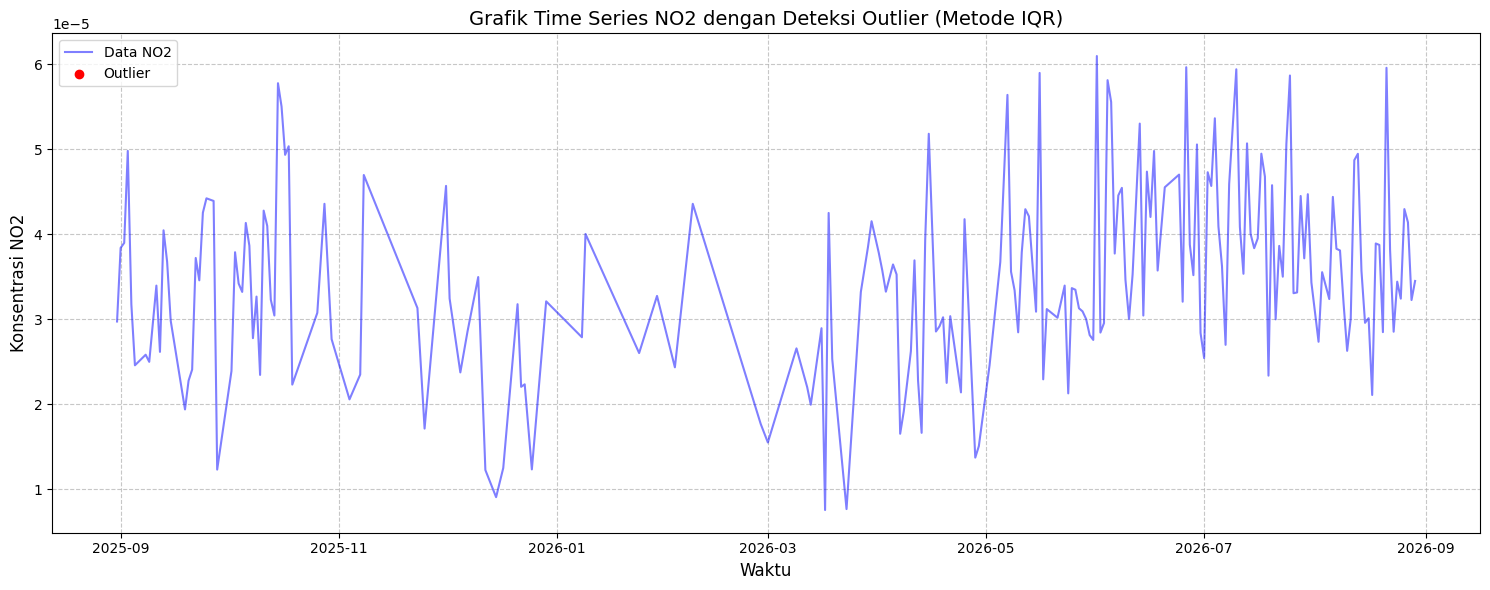

In [2]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt # Import matplotlib untuk visualisasi

# 1. Load & Clean Data
import pandas as pd
import matplotlib.pyplot as plt

# 1. Baca data
df = pd.read_csv("../../data/polutan/NO2_Outlier.csv")

# Pastikan kolom tanggal berformat datetime agar sumbu X rapi
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    
    # Mengurutkan data berdasarkan tanggal dari yang paling lama ke terbaru
    df = df.sort_values(by='date')
    
    # Jadikan tanggal sebagai indeks agar sumbu X pada grafik otomatis menyesuaikan
    df = df.set_index('date')

df_clean = df.dropna(subset=['NO2']).copy()

# 2. Deteksi Outlier dengan Metode IQR
Q1 = df_clean['NO2'].quantile(0.25)
Q3 = df_clean['NO2'].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Buat kolom penanda (True jika nilainya di luar batas IQR)
df_clean['Outlier'] = (df_clean['NO2'] < batas_bawah) | (df_clean['NO2'] > batas_atas)

jumlah_outlier = df_clean['Outlier'].sum()
print("Jumlah outlier (IQR):", jumlah_outlier)
print(f"Batas Bawah: {batas_bawah:.2f} | Batas Atas: {batas_atas:.2f}")

# 3. Visualisasi Grafik Time Series
plt.figure(figsize=(15, 6))

# Filter baris yang terdeteksi sebagai outlier
data_outlier = df_clean[df_clean['Outlier']]

# Plot garis tren utama untuk seluruh data NO2 (warna biru)
plt.plot(df_clean.index, df_clean['NO2'], color='blue', label='Data NO2', alpha=0.5)

# Plot titik khusus (scatter) untuk nilai outlier (warna merah)
plt.scatter(data_outlier.index, data_outlier['NO2'], color='red', label='Outlier', zorder=5)

# Pengaturan label dan judul
plt.title('Grafik Time Series NO2 dengan Deteksi Outlier (Metode IQR)', fontsize=14)
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Konsentrasi NO2', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Tampilkan grafik
plt.show()

## pengisian missing value

pengisian missing value

Jumlah missing value sebelum: 158
Jumlah missing value setelah: 1


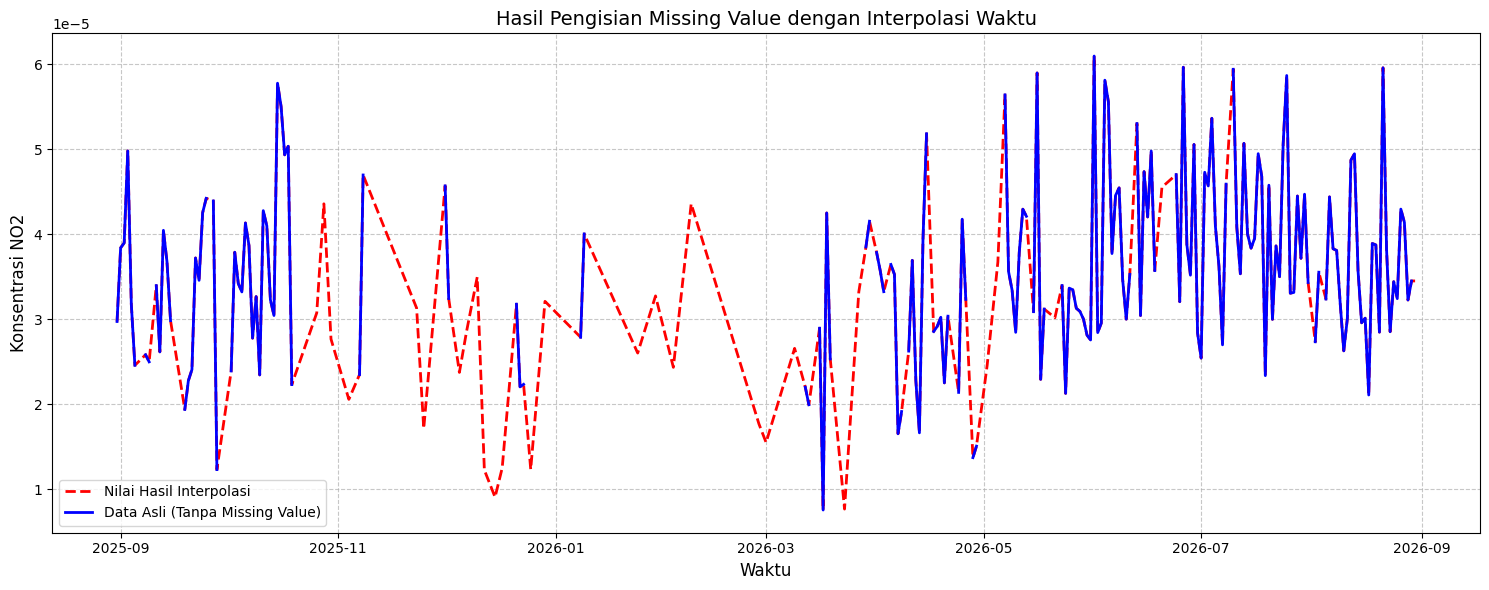

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Baca data yang memiliki missing value
df = pd.read_csv("../../data/polutan/NO2_Outlier.csv")

# 2. Persiapan kolom tanggal (sangat penting untuk urutan interpolasi)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(by='date') # Sorting tanggal
    df = df.set_index('date')      # Jadikan tanggal sebagai indeks

# Cek jumlah data kosong sebelum diproses
print("Jumlah missing value sebelum:", df['NO2'].isna().sum())

# Simpan data asli untuk keperluan visualisasi (opsional)
df['NO2_Asli'] = df['NO2']

# 3. Mengisi missing value dengan Interpolasi
# Menggunakan method='time' karena data kita adalah time series dengan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# Cek jumlah data kosong setelah diproses
print("Jumlah missing value setelah:", df['NO2'].isna().sum())

# 4. Simpan data yang sudah bersih ke file baru
# Reset index agar kolom 'date' kembali menjadi kolom biasa saat disimpan
df[['NO2']].reset_index().to_csv("../../data/polutan/NO2_after.csv", index=False)


# --- VISUALISASI HASIL INTERPOLASI ---
plt.figure(figsize=(15, 6))

# Plot data hasil interpolasi (garis merah di bawah)
plt.plot(df.index, df['NO2'], color='red', label='Nilai Hasil Interpolasi', linestyle='--', linewidth=2)

# Plot data asli menimpa di atasnya (garis biru)
plt.plot(df.index, df['NO2_Asli'], color='blue', label='Data Asli (Tanpa Missing Value)', linewidth=2)

plt.title('Hasil Pengisian Missing Value dengan Interpolasi Waktu', fontsize=14)
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Konsentrasi NO2', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Ekstraksi Fitur Deret Waktu (Time Series)

Dengan data deret waktu polutan udara yang konsisten (tanpa tanggal hilang dan tanpa _outlier_), kita dapat melangkah ke ekstraksi berbagai fitur statistik, temporal, maupun spektral. Fitur-fitur ini sangat berguna sebagai parameter *input* yang merepresentasikan karakteristik *trend* harian polutan ke dalam model _machine learning_ maupun _deep learning_.

Kita akan memanfaatkan modul pustaka Python bernama `tsfel` (_Time Series Feature Extraction Library_) guna mempermudah proses komputasi serta standarisasi ragam tipe fitur.

Berikut adalah sintaks kode implementasi untuk mengekstraksi sebanyak 68 fitur otomatis pada deret data NO₂ (dan berlaku perlakuan serupa untuk unsur polutan lainnya):

```python
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat data yang sudah dibersihkan ----------
df = pd.read_csv('../../data/polutan/NO2_after.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

# Pastikan data di-casting ke tipe numerik.
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

# Interpolasi terakhir untuk berjaga-jaga apabila terdapat sisa format nan
df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()
fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Inisiasi 68 Daftar Fitur TSFEL ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))

# ---------- 3. Fungsi ekstraksi dan penyeragaman output  ----------

# Fungsi bantuan (helper) merubah output multivariat TSFEL menjadi float tunggal/skalar
def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)

# Fungsi map pemanggilan fungsi TSFEL 
def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

# Lakukan ekstraksi iteratif pada fitur
row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang diekstrak pada {target_pollutant}: {extracted_features_final.shape[1]}")

# Export hasil ke file CSV
extracted_features_final.to_csv(f'../../data/polutan/{target_pollutant}_Widang_TSFEL.csv', index=False)
```

Data hasil ekstraksi fitur menggunakan TSFEL

In [4]:
df = pd.read_csv("../../data/polutan/NO2_Widang_TSFEL.csv")
df.head(5)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,4.070899e-07,0.011661,3.0,1.115315e-09,196.37298,0.000058,0.000032,0.000031,0.000008,0.00001,...,0.14513,0.472567,1.428401e-10,0.00188,0.000002,0.000015,2.148309,0.000015,2.444828e-10,0.0


## Penjelasan Domain TSFEL

Pustaka TSFEL membagi fitur deret waktu menjadi tiga domain utama untuk menganalisis data dari berbagai perspektif: **Statistik (Statistical)**, **Waktu (Temporal)**, dan **Frekuensi (Spectral)**. Berikut adalah penjelasan untuk setiap domain beserta fitur-fitur yang terdapat di dalamnya:

### 1. Domain Statistical
Domain statistik mengekstrak metrik kuantitatif dan karakteristik sebaran serta bentuk distribusi dari sinyal deret waktu tanpa mempertimbangkan urutan kemunculan waktunya. Fitur-fitur ini sangat baik untuk mengetahui rentang, kecenderungan memusat, dan variasi data.

* **`calc_max`, `calc_min`, `calc_mean`, `calc_median`**: Nilai maksimum, minimum, rata-rata, dan median dari deret waktu polutan.
* **`calc_std`, `calc_var`**: Standar deviasi dan varians yang mengukur tingkat penyebaran atau fluktuasi sinyal.
* **`ecdf`, `ecdf_percentile`, `ecdf_percentile_count`, `ecdf_slope`**: Metrik berdasarkan _Empirical Cumulative Distribution Function_ (ECDF) yang menggambarkan distribusi probabilitas kumulatif dari sinyal.
* **`hist_mode`**: Nilai kemunculan terbanyak (modus) dalam histogram data.
* **`interq_range`**: _Interquartile Range_ (IQR), mengukur rentang data di antara kuartil atas (Q3) dan kuartil bawah (Q1).
* **`kurtosis`**: Tingkat kelancipan (_peakedness_) dari distribusi data polutan dibandingkan dengan distribusi normal.
* **`skewness`**: Ukuran ketidaksimetrisan (kemiringan) dari distribusi data polutan.
* **`mean_abs_deviation`, `median_abs_deviation`**: Rata-rata dan median deviasi absolut yang memberikan ukuran kekokohan (_robustness_) sebaran data dari rata-rata atau mediannya.
* **`rms`**: _Root Mean Square_ (RMS), ukuran besaran rata-rata kuadrat dari sinyal, mencerminkan energi rata-rata data.

### 2. Domain Temporal
Domain temporal mengevaluasi sinyal dari segi urutan waktunya. Fitur ini sangat krusial untuk menemukan siklus, tren linier, kompleksitas atau tingkat kekacauan (_chaos_) pada data, serta autokorelasi dari suatu titik waktu ke waktu lainnya.

* **`abs_energy`**: Total energi absolut yang dikandung oleh sinyal seiring berjalannya waktu.
* **`auc`**: _Area Under the Curve_ (AUC), total luas area di bawah kurva sinyal polutan.
* **`autocorr`**: Autokorelasi, seberapa kuat sinyal polutan saat ini berkorelasi dengan waktu-waktu sebelumnya.
* **`average_power`**: Rata-rata kekuatan sinyal dalam domain waktu.
* **`calc_centroid`**: Titik pusat (centroid) sinyal di sepanjang sumbu waktu.
* **`dfa`**: _Detrended Fluctuation Analysis_ (DFA), untuk mengukur dependensi jangka panjang atau fraktalitas sinyal.
* **`distance`**: Total jarak lintasan pergerakan titik data dari awal hingga akhir.
* **`entropy`**: Skalar entropi yang mengukur tingkat ketidakteraturan, ketidakpastian, atau kerumitan pada deret waktu.
* **`higuchi_fractal_dimension`, `petrosian_fractal_dimension`**: Dimensi fraktal yang digunakan untuk menilai seberapa bergerigi atau kompleks sinyal secara matematis.
* **`hurst_exponent`**: Mengevaluasi apakah deret waktu memiliki tren memori jangka panjang (misalnya, jika polusi naik hari ini, apakah besok cenderung naik juga).
* **`lempel_ziv`**: Tingkat kompresibilitas atau kekayaan pola pada sinyal (kompleksitas deterministik).
* **`maximum_fractal_length`**: Panjang maksimal fraktal dari skala waktu yang bervariasi.
* **`mean_abs_diff`, `mean_diff`, `median_abs_diff`, `median_diff`**: Rata-rata dan median dari selisih atau selisih absolut antar data yang berurutan. Menggambarkan laju perubahan data harian.
* **`mse`**: _Mean Squared Error_, parameter rata-rata kesalahan kuadrat dari sinyal terkait model rata-ratanya.
* **`negative_turning`, `positive_turning`**: Jumlah titik belok di mana tren data berubah dari naik ke turun (negatif) dan turun ke naik (positif).
* **`neighbourhood_peaks`**: Memonitor titik-titik puncak di suatu lingkup observasi berdekatan.
* **`pk_pk_distance`**: Jarak dari lembah terendah ke puncak tertinggi (_Peak-to-Peak_).
* **`slope`**: Kemiringan tren data linear secara keseluruhan (naik/turun).
* **`sum_abs_diff`**: Total akumulasi jumlah perbedaan absolut dari satu titik waktu ke waktu berikutnya.
* **`zero_cross`**: Seberapa sering sinyal menyilang nilai nol (atau memotong garis _baseline_).

### 3. Domain Spectral
Domain spektral memproses deret waktu dengan mentransformasikannya ke dalam ranah frekuensi (menggunakan algoritma spektrum fourier atau dekomposisi wavelet). Fitur pada domain ini sangat bagus untuk menganalisis sifat periodik dan kepadatan osilasi gelombang yang tersembunyi.

* **`fundamental_frequency`**: Frekuensi dasar yang paling menonjol dalam sinyal, menandakan siklus polutan terkuat.
* **`max_frequency`**: Frekuensi tertinggi yang dicatat pada analisis spektrum.
* **`median_frequency`**: Frekuensi median pembagi tengah total daya pada spektrum sinyal polutan.
* **`human_range_energy`**: Energi sinyal dalam rentang frekuensi tertentu (lebih spesifik untuk pergerakan frekuensi pada rentang manusia).
* **`lpcc`, `mfcc`**: _Linear Prediction Cepstral Coefficients_ dan _Mel-Frequency Cepstral Coefficients_, representasi padat terkait spektrum sinyal yang biasa digunakan dalam pemrosesan suara, berguna memetakan tekstur frekuensi polutan.
* **`max_power_spectrum`**: Nilai daya (energi) tertinggi pada frekuensi dominan dalam seluruh pita spektrum.
* **`power_bandwidth`**: Lebar pita frekuensi tempat sebagian besar energi sinyal difokuskan.
* **`spectral_centroid`**: Titik berat frekuensi, mengindikasikan apakah energi spektrum lebih condong ke frekuensi tinggi atau rendah.
* **`spectral_decrease`, `spectral_slope`**: Pengukuran tren seberapa curam/cepat daya spektrum menurun pada frekuensi tinggi.
* **`spectral_distance`**: Ukuran jarak antara profil frekuensi berdekatan (kestabilan spektrum).
* **`spectral_entropy`**: Entropi spektral, seberapa datar atau bervariasi distribusi energi pada keseluruhan pita frekuensi (menandakan keteraturan sinyal siklik).
* **`spectral_kurtosis`, `spectral_skewness`**: Parameter bentuk untuk kurva densitas spektrum (menilai kelancipan dan kemiringan pita spektral).
* **`spectral_positive_turning`**: Jumlah belokan (titik naik) pada plot kepadatan spektral frekuensi.
* **`spectral_roll_off`, `spectral_roll_on`**: Titik frekuensi di mana presentase mayoritas daya (misal 95%) telah terkonsentrasi; berguna untuk penyaringan sinyal bising/noise.
* **`spectral_spread`, `spectral_variation`**: Penyebaran atau lebar pita variasi spektrum di sekeliling _centroid_.
* **`spectrogram_mean_coeff`**: Rata-rata tingkat magnitudo atau koefisien yang diambil dari keseluruhan hasil matriks spektrogram waktu-frekuensi.
* **`wavelet_abs_mean`, `wavelet_energy`, `wavelet_entropy`, `wavelet_std`, `wavelet_var`**: Parameter dari hasil Transformasi Wavelet (rata-rata mutlak, energi, entropi, standar deviasi, dan varians koefisien wavelet), berguna untuk mengungkap struktur waktu dan frekuensi secara simultan yang dapat berubah-ubah.